## IN_DATA
- `df_raw`

## OUT_DATA
- `df_equal`
- `df_raw`

## MAIN_FUNCTIONS
- `gen_df_equal` *
- `get_all_diameter`
- `label_raw_traj_from_equalized_traj`

## PACKAGE

In [1]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.equal import *

## BASH PARAMETERS

In [2]:
mouse_id = 3 #int(sys.argv[1])

In [3]:
# set directories
tag = f"mouse_{mouse_id}"
in_dir = project_dir / "results" / tag
out_dir = in_dir
#
if not os.path.exists(in_dir):
    os.makedirs(in_dir)

## LOAD

In [4]:
# load metadata
n_sessions = n_sessions_dict[mouse_id]

# load perspective transform
M_dict, img_dict, xy_anchor_dict, base_key = pickle.load(open(project_dir / 'results' / "dat_perspective", "rb"))

# load df
df_raw = pickle.load(open(in_dir / "df_raw", "rb"))

## GLOBAL PARAMETERS

In [5]:
upsampl_fac = 2
d_downsampl = d_tile / fs_equal  # this determines the point-to-point distance
d_pair_th = d_tile / fs_pair_th # used to assign wall following

## RUN: generate df_equal from df_raw

In [6]:
## RUN 
# mouse 3: 2m for upsampl_fac=2
# mouse 10: 42m for upsampl_fac=2 (a bit too long, consider pre-splitting into two mouse ids)
df_equal = gen_df_equal(df_raw, d_downsampl, upsampl_fac=upsampl_fac)

## RUN: attr small diameter to `df_equal` and `df_raw`

### step 1: get small diameter of equalized traj from `df_equal` and assign to `df_raw`

In [7]:
## RUN (1m for mouse 10)
# get diameters
t0_all = df_equal.index.values
diameter_all, bool_small_all = get_all_diameter(t0_all, df_equal)

# attr
df_equal['diameter'] = diameter_all
df_equal['is_small'] = bool_small_all

# attr df_raw
df_raw = label_raw_traj_from_equalized_traj(bool_small_all, 'is_small', df_equal, df_raw)

In [8]:
df_raw.is_small.mean(), df_equal.is_small.mean()

(0.12516299222284488, 0.037345162370271176)

## PICKLE

In [9]:
df_equal.to_pickle(out_dir / "df_equal")
df_raw.to_pickle(out_dir / "df_raw")

## TEST

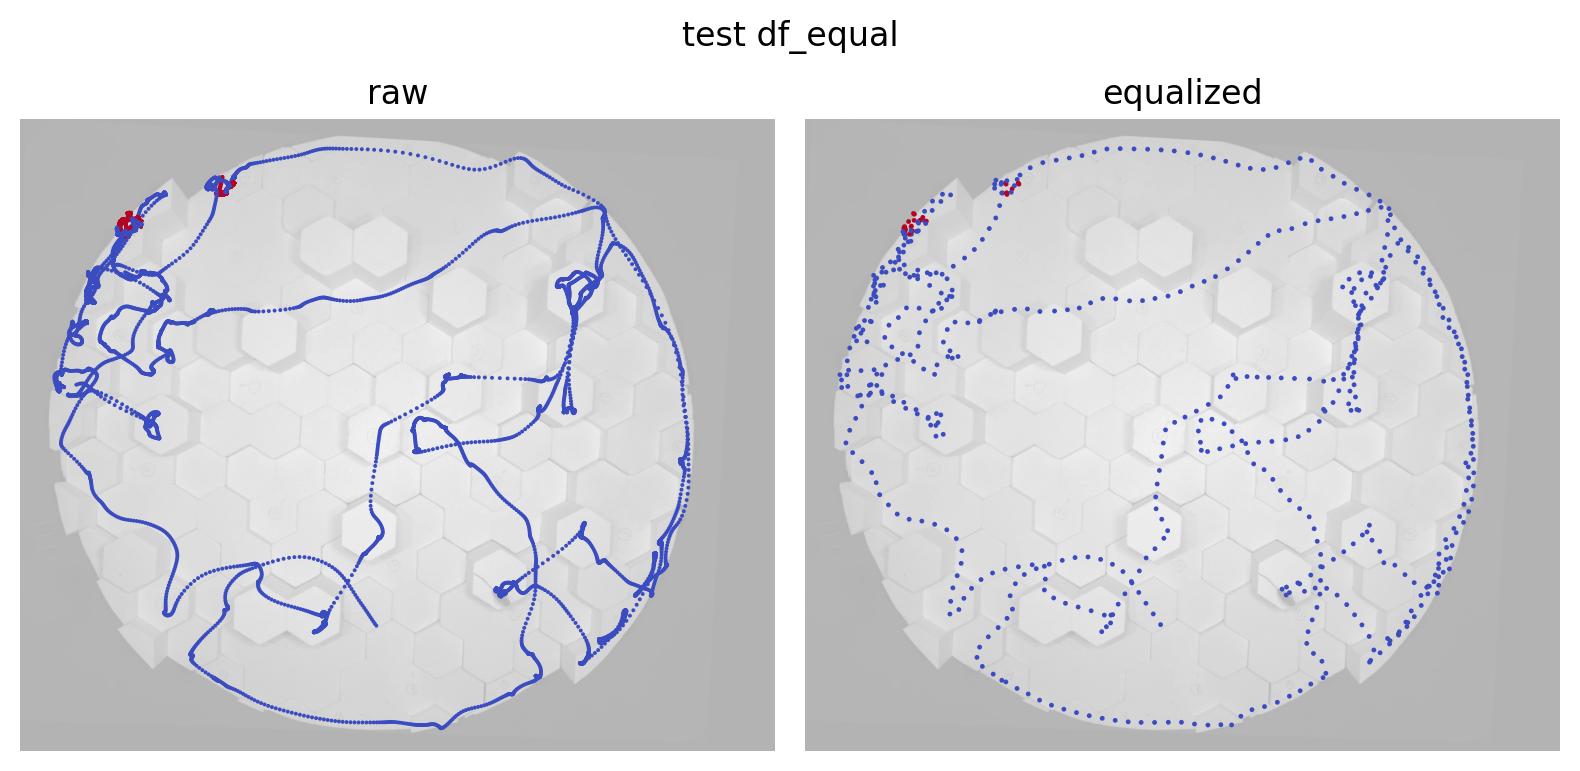

In [10]:
t0, t1 = len(df_equal) // 100 * 22, len(df_equal) // 100 * 23
rt0, rt1 = df_equal.loc[[t0, t1], "t_raw"].values
session = df_equal.loc[t0, "session"]
img = img_dict[(mouse_id, session)]
#
plt.figure(figsize=(8, 4), dpi=200)
plt.suptitle('test df_equal')
plt.subplot(121)
plt.title("raw")
plt.imshow(img, zorder=0, alpha=0.3, origin="lower")
xy = df_raw[rt0:rt1][["xg", "yg"]].values.T
bool_small = df_raw[rt0:rt1]["is_small"].values
plt.scatter(*xy, c=bool_small, cmap="coolwarm", s=2, edgecolors="none")
plt.axis("off")

plt.subplot(122)
plt.title("equalized")
plt.imshow(img, zorder=0, alpha=0.3, origin="lower")
xy = df_equal[t0:t1][["xe", "ye"]].values.T
bool_small = df_equal[t0:t1]["is_small"].values
plt.scatter(*xy, c=bool_small, cmap="coolwarm", s=3, edgecolors="none")
plt.axis("off")

plt.tight_layout()
plt.savefig(out_dir / "df_equal_test.png")

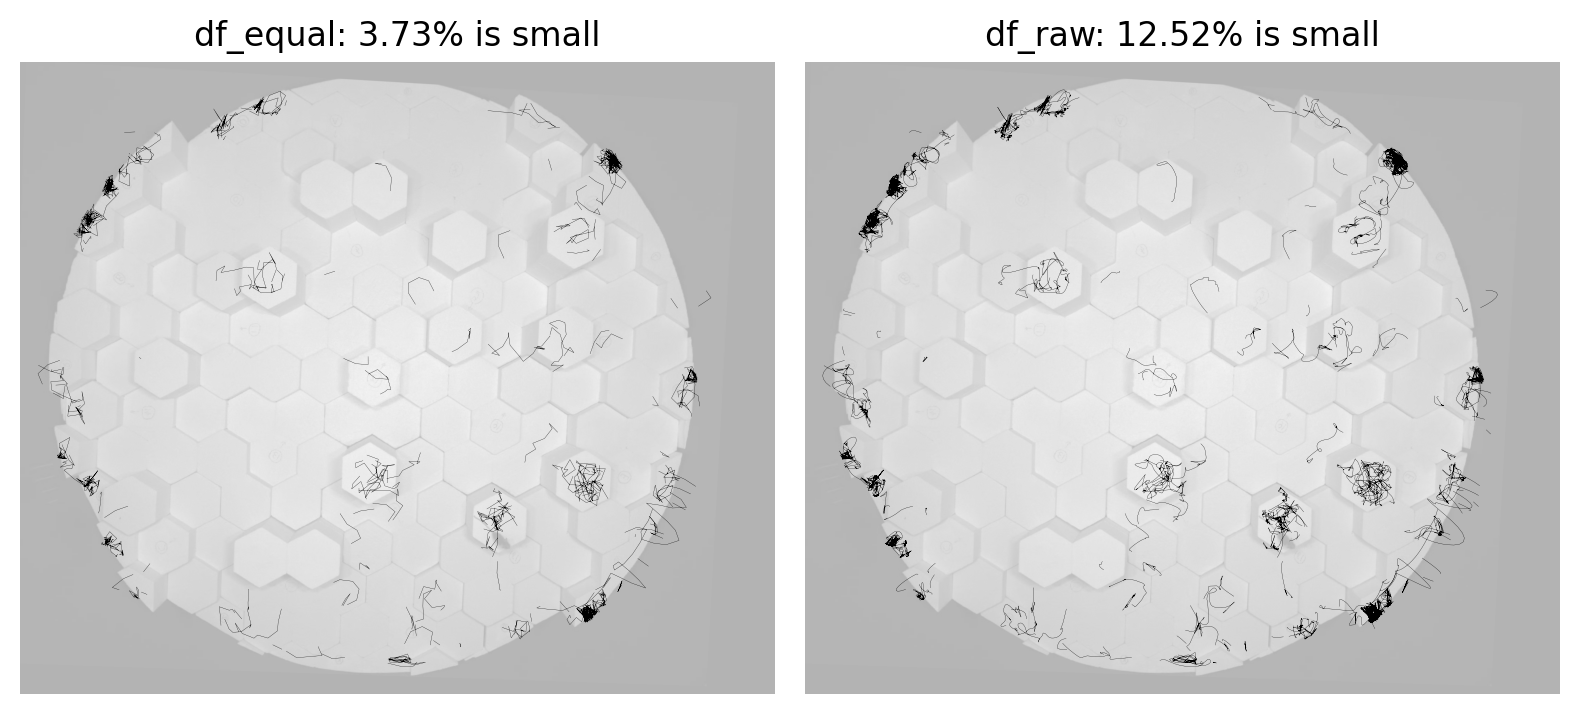

In [11]:
img = img_dict[(mouse_id, session)]
#
plt.figure(figsize=(8, 8), dpi=200)
plt.subplot(121)
plt.title(f'df_equal: {df_equal.is_small.mean()*100:.2f}% is small')
xy_all = df_equal[['xe','ye']].values
mask = ~df_equal.is_small.values
xy_all_mask = xy_all.copy()
xy_all_mask[mask] = np.nan
plt.imshow(img, zorder=0, alpha=0.3, origin="lower")
plt.plot(xy_all_mask[:, 0], xy_all_mask[:, 1], c='k', lw=.1, zorder=1)
plt.axis("off")

plt.subplot(122)
plt.title(f'df_raw: {df_raw.is_small.mean()*100:.2f}% is small')
xy_all = df_raw[['xg','yg']].values
mask = ~df_raw.is_small.values
xy_all_mask = xy_all.copy()
xy_all_mask[mask] = np.nan
plt.imshow(img, zorder=0, alpha=0.3, origin="lower")
plt.plot(xy_all_mask[:, 0], xy_all_mask[:, 1], c='k', lw=.1, zorder=1)
plt.axis("off")

plt.tight_layout()
plt.savefig(out_dir / "df_equal_small_diameter_test.png")